In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [2]:
load_dotenv()  # Load environment variables from .env file

True

In [3]:
model = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0
)

In [24]:
class BlogState(TypedDict):
    topic: str
    outline: str
    content: str
    evaluate: str
    

In [17]:
def create_outline(state: BlogState) -> BlogState:
    #extract topic from state
    topic = state['topic']

    #create outline using the topic
    prompt = f"Create a detailed outline for a blog post about {topic}."
    outline = model.invoke(prompt).content

    #update state with the outline
    state['outline'] = outline # type: ignore
    return state


In [25]:
def create_content(state: BlogState) -> BlogState:
    #extract outline from state
    title = state['topic']
    outline = state['outline']

    #create content using the outline
    prompt = f"Create a detailed blog post titled '{title}' based on the following outline: {outline}."
    content = model.invoke(prompt).content

    #update state with the content
    state['content'] = content # type: ignore
    return state

In [26]:
def evaluate_content(state: BlogState) -> BlogState:
    #extract content from state
    outline = state['outline']
    content = state['content']

    #evaluate the content
    prompt = f"Evaluate the following blog post for clarity, coherence, and engagement: {content} from the outline: {outline}. Provide feedback and suggestions for improvement."
    evaluation = model.invoke(prompt).content

    #update state with the evaluation
    state['evaluate'] = evaluation # type: ignore
    return state

In [27]:
graph = StateGraph(BlogState)

graph.add_node('create_outline',create_outline)
graph.add_node('create_content', create_content)
graph.add_node('evaluate_content', evaluate_content)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_content')
graph.add_edge('create_content', 'evaluate_content')
graph.add_edge('evaluate_content', END)

#compile the workflow
workflow = graph.compile()

In [28]:
#Execute the workflow
initial_state = {'topic': "Rise of AI in India"}
final_state = workflow.invoke(initial_state) # type: ignore
print(final_state)

{'topic': 'Rise of AI in India', 'outline': '**Title:** "The Rise of AI in India: Opportunities, Challenges, and Future Prospects"\n\n**I. Introduction**\n\n* Brief overview of the growing importance of Artificial Intelligence (AI) globally\n* Significance of India\'s AI landscape and its potential for growth\n* Thesis statement: India is poised to become a major player in the global AI market, driven by government initiatives, technological advancements, and entrepreneurial spirit.\n\n**II. Government Initiatives and Policies**\n\n* Overview of the Indian government\'s AI strategy and policies\n* Key initiatives such as:\n\t+ National AI Portal\n\t+ AI for All program\n\t+ AI for Social Good initiative\n\t+ Data Governance Framework\n* Analysis of the impact of these initiatives on the growth of AI in India\n\n**III. Technological Advancements**\n\n* Overview of the key AI technologies being developed in India, including:\n\t+ Machine Learning (ML)\n\t+ Natural Language Processing (NL

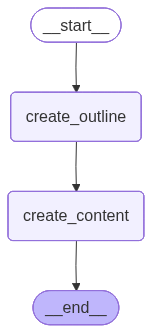

In [14]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [22]:
print(final_state['outline'])

**Title:** "The Rise of AI in India: Opportunities, Challenges, and Future Prospects"

**I. Introduction**

* Brief overview of the growing importance of Artificial Intelligence (AI) globally
* Significance of India's AI landscape and its potential for growth
* Thesis statement: India is poised to become a major player in the global AI market, driven by government initiatives, technological advancements, and entrepreneurial spirit.

**II. Government Initiatives and Policies**

* Overview of the Indian government's AI strategy and policies
* Key initiatives such as:
	+ National AI Portal
	+ AI for All program
	+ AI for Social Good initiative
	+ Data Governance Framework
* Analysis of the impact of these initiatives on the growth of AI in India

**III. Technological Advancements**

* Overview of the key AI technologies being developed in India, including:
	+ Machine Learning (ML)
	+ Natural Language Processing (NLP)
	+ Computer Vision
	+ Robotics
* Discussion of the role of Indian startu

In [23]:
print(final_state['content'])

**The Rise of AI in India: Opportunities, Challenges, and Future Prospects**

**Introduction**

Artificial Intelligence (AI) has become a transformative force globally, revolutionizing industries and transforming the way we live and work. As the world becomes increasingly dependent on AI, India is poised to become a major player in the global AI market. With its large talent pool, entrepreneurial spirit, and government initiatives, India is well-positioned to harness the power of AI and drive growth in various sectors. In this blog post, we will explore the rise of AI in India, its opportunities, challenges, and future prospects.

**Government Initiatives and Policies**

The Indian government has recognized the potential of AI to drive economic growth and has launched several initiatives to promote its development and adoption. Some key initiatives include:

1. **National AI Portal**: Launched in 2018, the National AI Portal is a platform that provides information on AI-related policie

In [29]:
print(final_state['evaluate'])

**Overall Evaluation**

The blog post "The Rise of AI in India: Opportunities, Challenges, and Future Prospects" is well-structured and provides a comprehensive overview of the AI landscape in India. The author has done a good job of covering various aspects of AI, including government initiatives, technological advancements, industry adoption, and startup ecosystem.

**Strengths:**

1. **Clear structure**: The blog post follows a logical structure, making it easy to follow and understand.
2. **Comprehensive coverage**: The author has covered various aspects of AI in India, providing a comprehensive overview of the topic.
3. **Use of examples**: The author has used examples and case studies to illustrate the benefits and challenges of AI adoption in India.
4. **References**: The author has provided a list of references, which is a good practice for academic and professional writing.

**Weaknesses:**

1. **Lack of depth**: While the blog post provides a good overview of the AI landscape